In [15]:
import pickle
import numpy as np
import tools_file
import tools_plot

convention = {
    "X": "+Z",
    "Y": "-X",
    "Z": "-Y",
}

# 构造 convention shift 矩阵
P_SHIFT = np.array([0, 0, 0])
R_SHIFT = np.array([[0, 0, 1], 
                    [-1, 0, 0], 
                    [0, -1, 0]])
TF_SHIFT = np.eye(4)
TF_SHIFT[:3, :3] = R_SHIFT
TF_SHIFT[:3, 3] = P_SHIFT



dict_keys(['t', 'ee_pos', 'ee_axis_angle', 'gripper_width'])


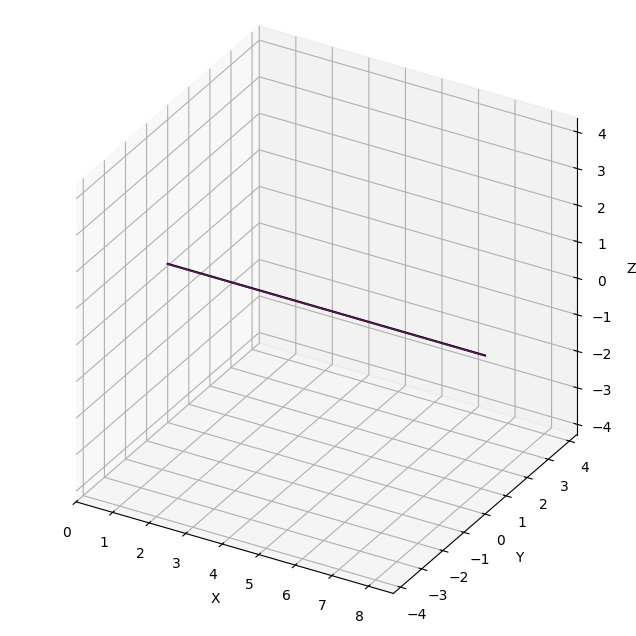

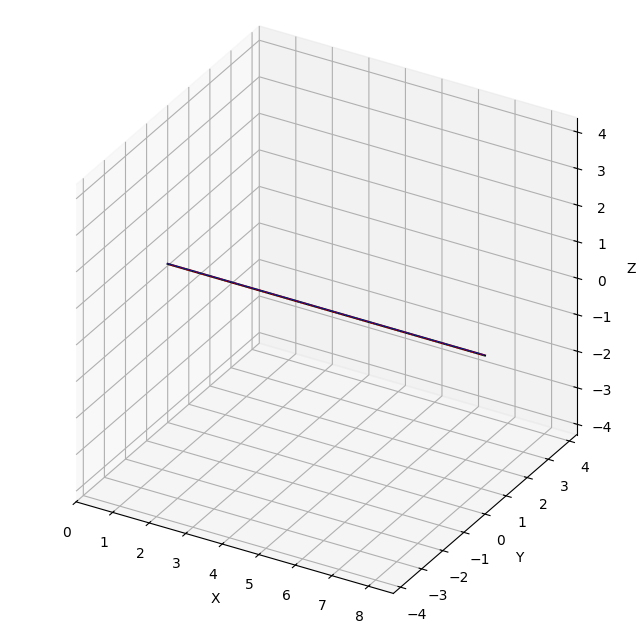

In [21]:
pkl_path = "data/pushing.pkl"
tf_umi = tools_file.pkl_to_tf(pkl_path)

umi_source_data = pickle.load(open(pkl_path, "rb"))
print(umi_source_data[0].keys())

tools_plot.plot_3d(tf_umi[0]["tf"])
tools_plot.plot_3d(tf_umi[0]["tf"] @ TF_SHIFT.T)

### Correct UMI trajectory convention

In [17]:
tf_umi_mod = []
for item in tf_umi:
    tf_umi_mod.append({
        "t": item["t"],
        "tf": item["tf"] @ TF_SHIFT.T,
        "gripper_width": item["gripper_width"],
    })

pkl_list = tools_file.tf_to_pkl(tf_umi_mod)
pickle.dump(pkl_list, open("data/pushing_converted.pkl", "wb"))


### Double Check

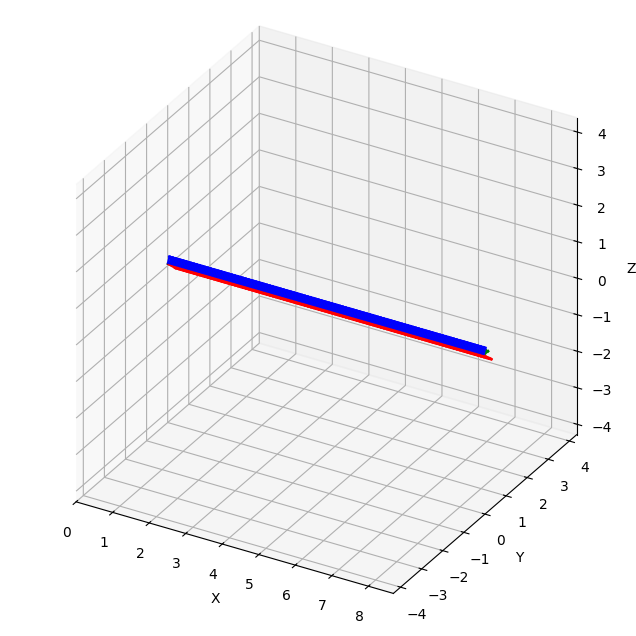

In [19]:
pkl_list = tools_file.pkl_to_tf("data/pushing_converted.pkl")
tools_plot.plot_3d(pkl_list[0]["tf"], arrow_length=0.5)